# Coherent-Basis Optimization for Bosonic Quantum Codes

**C. Blake, G. Zheng, G. Lee, and L. Jiang — March 2026**

This notebook aggregates all key results from the jiang-research project:
1. **Coherent-basis framework** — analytic fidelity formulas
2. **GKP state preparation** — fixed-circuit pipelines, comparison with adaptive protocols
3. **Fock state preparation** — extending coherent-basis optimization to number states
4. **Floating-basis codes** — jointly optimized encoder-decoder pairs
5. **ECD Optimization Tool Examples** - how to use the autodiff optimizers

In [1]:
import sys
sys.path.insert(0, 'coherax')
import numpy as np
import scipy.special as sp
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
import dynamiqs as dq

# Core library
from coherax import (
    g, channel_from_b, GKP_N,
    gkp_coherent_dm, CoherentKet,
    analytic_fidelity_wrapper,
    analytic_fidelity_transfer_wrapper,
    analytic_fidelity_fock_wrapper,
    analytic_fidelity_fock_state,
    make_pureloss_fock,
    make_transpose_for_pureloss,
    apply_kraus_map_nonorm, apply_kraus_map, dag,
    compose_ECD_layers, traceout_unitary,
    circuit_params_to_time, dqfock_dm, dqtrace, dqptrace,
    dqdag, dqcoherent, dqdisplace, dqtensor,
    von_neumann_entropy, make_thermalloss_fock,
    coherent_overlap, dqsqueeze,
    pureloss_coherent_info_from_kets,
    pureloss_coherent_info_from_coherent_kets,
    optimize_ECD_state_prep,
    optimize_ECD_state_transfer
)
# from staging.transpose_channel_claude import ( # TODO
#     coherent_ket_to_fock, build_gkp_states,
#     entanglement_fidelity, entanglement_fidelity_no_recovery,
# )
# from staging.worstcase_optimizer_claude import (
#     entanglement_fidelity_displacement,
# )
# from staging.fock_fidelity_claude import (
#     cross_validate_fock, analytic_fidelity_fock_state, circuit_time_us,
# )
# from staging.benchmark_codes_claude import (
#     cat_2leg, cat_4leg, binomial_order1, gkp_hex, gkp_square,
#     nbar_code, find_gkp_delta_for_nbar, find_cat_alpha_for_nbar,
#     entanglement_fidelity_fock,
#     singh_gkp_gaussian, singh_gkp_binomial, nbar_fock_ket,
# )

# Plot style
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'legend.fontsize': 9,
    'figure.dpi': 150,
})

DATA = 'testing_data'
FIGS = 'figs'

print(f'JAX devices: {jax.devices()}')
print(f'Fock truncation: N = {GKP_N}')
print(f'x64 enabled: {jax.config.jax_enable_x64}')

JAX devices: [CpuDevice(id=0)]
Fock truncation: N = 100
x64 enabled: True


---
## 1. Coherent-Basis Framework

A depth-$n$ CD+R circuit on $|0\rangle_{\text{cav}} \otimes |0\rangle_{\text{qubit}}$ yields Kraus operators:
$$K_j = \sum_{i=1}^{N_l} \alpha_{j,i}\, D(\beta_{j,i}), \quad N_l = 2^n$$

**Coherent-target fidelity:**
$$F = \sum_j \left|\sum_i \alpha_{j,i} \sum_a c_a^* e^{-|\beta_{j,i} - d_a|^2/2 + i\,\text{Im}(\bar{d}_a \beta_{j,i})} \right|^2$$

**Fock-target fidelity**:
$$F_m = \sum_j \left|\frac{1}{\sqrt{m!}} \sum_i \alpha_{j,i}\, e^{-|\beta_{j,i}|^2/2}\, \beta_{j,i}^m \right|^2$$

Both are closed-form, JAX-differentiable functions of $(\alpha, \beta)$ from `g()`.

---
## 2. GKP State Preparation

### 2.1 Pipeline Protocols ($\Delta = 0.34$)

In [2]:
def fock_pipeline_fidelity(prep_params, transfer_params, target_dm):
    """Evaluate end-to-end pipeline fidelity in Fock basis."""
    vacuum = dqfock_dm(GKP_N, 0)
    rho_prep = apply_kraus_map(traceout_unitary(compose_ECD_layers(prep_params)), vacuum)
    rho_final = apply_kraus_map(traceout_unitary(compose_ECD_layers(transfer_params)), rho_prep)
    return float(jnp.real(dqtrace(rho_final @ target_dm))) # evaluated in Fock basis

def determine_purity(prep_params, transfer_params, target_dm):
    """Evaluate end-to-end pipeline fidelity in Fock basis while determining intermediate ancilla purity."""
    vacuum = dqfock_dm(GKP_N, 0)
    vacuum_prod = dqtensor(vacuum,dqfock_dm(2,0))
    U_1 = compose_ECD_layers(prep_params)
    full_state_prep = U_1@vacuum_prod@dqdag(U_1)
    oscillator_state_1 = dqptrace(full_state_prep,0,(GKP_N,2))
    qubit_state_1 = dqptrace(full_state_prep,1,(GKP_N,2))
    print("Intermediate 'Traceout' Purity",float(jnp.real(jnp.trace(qubit_state_1@qubit_state_1))))
    full_state_2 = dqtensor(oscillator_state_1,dqfock_dm(2,0))
    U_2 = compose_ECD_layers(transfer_params)
    full_state_transfer = U_2@full_state_2@dqdag(U_2)
    oscillator_state_2 = dqptrace(full_state_transfer,0,(GKP_N,2))
    qubit_state_2 = dqptrace(full_state_2,1,(GKP_N,2))
    print("Final 'Traceout' Purity",float(jnp.real(jnp.trace(qubit_state_2@qubit_state_2))))
    return float(jnp.real(dqtrace(oscillator_state_2 @ target_dm))) # evaluated in Fock basis

# State preparation comparison table
# Load our pipeline params and recompute fidelity + time
import json
Delta_034 = 0.34

x3_prep = np.load(f'{DATA}/exp_C1_x3_100restart.npz', allow_pickle=True)
x4_prep = np.load(f'{DATA}/exp_C2_x4_100restart.npz', allow_pickle=True)
x3_to_x3y3 = np.load(f'{DATA}/GKP_D034_x3_to_x3y3_prep.npz')
x3_prep_params = jnp.array(x3_prep['params'])
x4_prep_params = jnp.array(x4_prep['params'])
x3_to_x3y3_params = jnp.array(x3_to_x3y3["params"])

In [3]:
# Coherent GKP targets (N_trunc_y=0 means 1D marginal)
gkp_x3 = gkp_coherent_dm(mu=0, N_trunc=3, Delta=Delta_034, lattice="square", N_trunc_y=0)
gkp_x4 = gkp_coherent_dm(mu=0, N_trunc=4, Delta=Delta_034, lattice="square", N_trunc_y=0)
gkp_3 = gkp_coherent_dm(mu=0, N_trunc=3, Delta=Delta_034, lattice="square")
rho_x3_fock = gkp_x3.to_fock_basis()
rho_gkp3_fock = gkp_3.to_fock_basis()

# Recompute fidelities from params
x3_prep_fid = float(analytic_fidelity_wrapper(gkp_x3, x3_prep_params, 2 ** x3_prep_params.shape[0]))
x4_prep_fid = float(analytic_fidelity_wrapper(gkp_x4, x4_prep_params, 2 ** x4_prep_params.shape[0]))
x3_to_x3y3_fid = float(analytic_fidelity_transfer_wrapper(gkp_x3, gkp_3, jnp.expand_dims(x3_to_x3y3_params,0), 2 ** x3_to_x3y3_params.shape[0], 1))
x3_prep_time = circuit_params_to_time(x3_prep_params)*1e6
x4_prep_time = circuit_params_to_time(x4_prep_params)*1e6
x3_to_x3y3_time = circuit_params_to_time(x3_to_x3y3_params)*1e6

/opt/miniconda3/envs/jiang/lib/python3.11/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=complex64 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


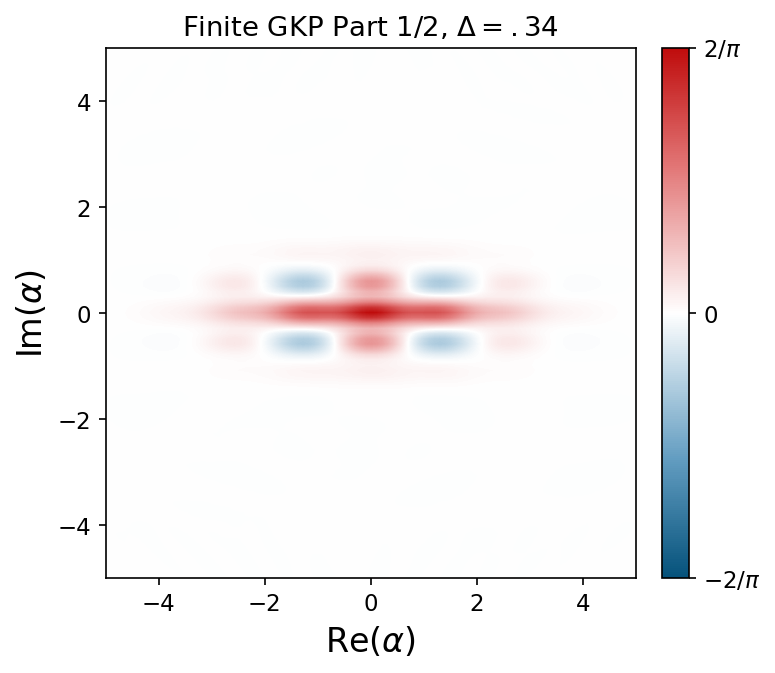

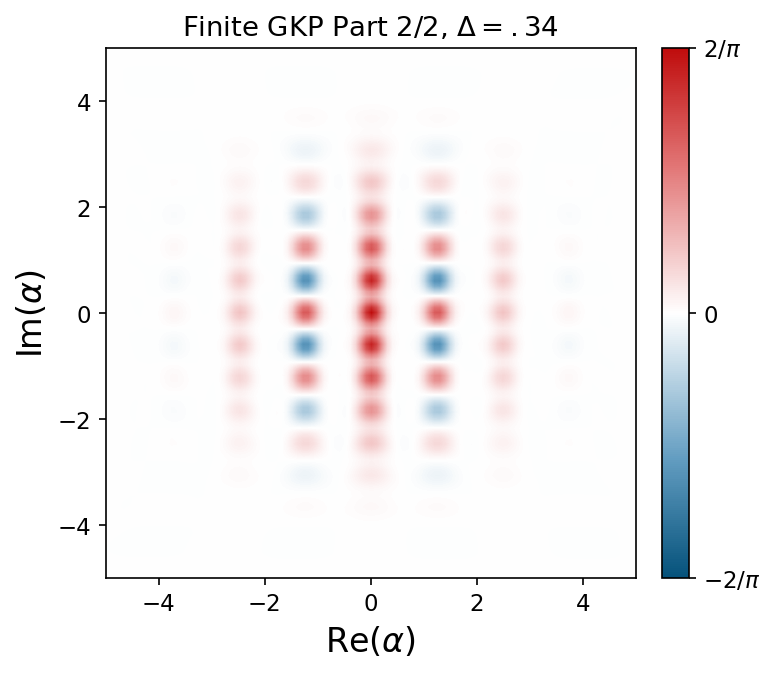

In [4]:
prepped_x3 = apply_kraus_map(traceout_unitary(compose_ECD_layers(x3_prep_params)),dqfock_dm(GKP_N,0))
dq.plot.wigner(prepped_x3)
plt.title(rf"Finite GKP Part 1/2, $\Delta = .34$")
plt.xlabel(rf"Re($\alpha$)",fontsize=16)
plt.ylabel(rf"Im($\alpha$)",fontsize=16)
plt.show()
dq.plot.wigner(apply_kraus_map(traceout_unitary(compose_ECD_layers(x3_to_x3y3_params)),prepped_x3))
plt.title(rf"Finite GKP Part 2/2, $\Delta = .34$")
plt.xlabel(rf"Re($\alpha$)",fontsize=16)
plt.ylabel(rf"Im($\alpha$)",fontsize=16)
plt.show()

In [5]:
# Recompute pipeline fidelity (vacuum -> X3 prep -> X3Y3 transfer -> compare)
PIPELINE_F = determine_purity(x3_prep_params, x3_to_x3y3_params, rho_gkp3_fock)
PIPELINE_1F = 1.0 - PIPELINE_F
PIPELINE_T = float(circuit_params_to_time(x3_prep_params) * 1e6) + \
             float(circuit_params_to_time(x3_to_x3y3_params) * 1e6)
PIPELINE_LAYERS = x3_prep_params.shape[0] + x3_to_x3y3_params.shape[0]

# Also build the pipeline output density matrix (needed for stabilizer cell)
vacuum = dqfock_dm(GKP_N, 0)

print(f'X3Y3 pipeline: F = {PIPELINE_F:.6f}, 1-F = {PIPELINE_1F:.2e}, '
      f'{PIPELINE_LAYERS} layers, T = {PIPELINE_T:.2f} us')

print('\nGKP State Preparation Comparison (Delta=0.34)')
print('=' * 75)
print(f'{"Protocol":<22s} {"Type":<10s} {"Layers":<8s} {"1-F":<12s} {"Time (us)":<10s}')
print('-' * 75)

prep_data = [
    ('X3Y3 pipeline',  'Fixed',    PIPELINE_LAYERS, PIPELINE_1F, PIPELINE_T),
    ('X3 1D marginal',   'Fixed',    x3_prep_params.shape[0], 1-x3_prep_fid,    x3_prep_time),
    ('X4 1D marginal',   'Fixed',    x4_prep_params.shape[0], 1-x4_prep_fid,    x4_prep_time),
]

for name, typ, layers, infid, time in prep_data:
    print(f'{name:<22s} {typ:<10s} {layers:<8d} {infid:<12.2e} {time:<10.2f}')

Intermediate 'Traceout' Purity 0.9999890557497803
Final 'Traceout' Purity 0.999999874724805
X3Y3 pipeline: F = 0.999804, 1-F = 1.96e-04, 23 layers, T = 4.81 us

GKP State Preparation Comparison (Delta=0.34)
Protocol               Type       Layers   1-F          Time (us) 
---------------------------------------------------------------------------
X3Y3 pipeline          Fixed      23       1.96e-04     4.81      
X3 1D marginal         Fixed      10       1.22e-05     2.05      
X4 1D marginal         Fixed      10       1.24e-05     2.06      


---
## 3. Fock State Preparation

Using $\langle n|\beta\rangle = e^{-|\beta|^2/2} \beta^n / \sqrt{n!}$, we optimize CD+R circuits for various Fock states.

In [6]:
# Load Fock preparation params and recompute fidelities
fock = np.load(f'{DATA}/fock_preparation.npz') # TODO find the rest
fock_depths = [4, 6, 8, 10]
fock_states = list(range(1,9))

In [7]:
def determine_purity_fock_prep(params, target_state):
    U = compose_ECD_layers(params)
    vacuum_prod = dqtensor(dqfock_dm(GKP_N,0),dqfock_dm(2,0))
    prepped_state = U@vacuum_prod@dqdag(U)
    qubit_state = dqptrace(prepped_state,1,(GKP_N,2))
    return float(jnp.real(jnp.trace(qubit_state@qubit_state)))

In [8]:
print('Fock State Preparation Results (recomputed from params)')
print('=' * 82)
print(f'{"Target":>8s} {"Depth":>6s} {"N_l":>6s} {"F":>12s} {"1-F":>12s} {"Time":>8s} {"Ancilla Purity":>12s}')
print('-' * 82)

results = {n: {d: {"fidelity": -1, "time_us": -1} for d in fock_depths} for n in fock_states}  # store for later use in Wigner plot
for tn in fock_states:
    for d in fock_depths:
        p = f'n{tn}_d{d}'
        params = jnp.array(fock[f'{p}_params'])
        N_l = 2 ** d

        # Recompute fidelity from params via analytic formula
        fid_recomp = jnp.clip(float(analytic_fidelity_fock_wrapper(tn, params, N_l)),max=1.0)
        prepped_state = apply_kraus_map(traceout_unitary(compose_ECD_layers(params)),dqfock_dm(GKP_N,0))
        fid_recomp = jnp.real(jnp.trace(prepped_state@dqfock_dm(GKP_N,tn)))
        ancilla_purity = determine_purity_fock_prep(params,dqfock_dm(GKP_N,tn))
        t = circuit_params_to_time(params)*1e6

        results[tn][d]["fidelity"] = fid_recomp
        results[tn][d]["time_us"] = t

        print(f'{f"  |{tn}>":>8s} {d:>6d} {N_l:>6d} {fid_recomp:>12.8f} '
              f'{1-fid_recomp:>12.2e} {t:>8.2f} {ancilla_purity:>12.8f}')
    print()

Fock State Preparation Results (recomputed from params)
  Target  Depth    N_l            F          1-F     Time Ancilla Purity
----------------------------------------------------------------------------------
     |1>      4     16   0.99843238     1.57e-03     0.62   0.99785840
     |1>      6     64   0.99999720     2.80e-06     0.66   0.99999506
     |1>      8    256   0.99999985     1.53e-07     0.76   0.99999999
     |1>     10   1024   0.99999983     1.70e-07     0.85   1.00000003

     |2>      4     16   0.97401125     2.60e-02     0.89   0.97179799
     |2>      6     64   0.99994669     5.33e-05     1.16   0.99993341
     |2>      8    256   0.99999860     1.40e-06     1.01   0.99999946
     |2>     10   1024   0.99999934     6.58e-07     1.07   0.99999948

     |3>      4     16   0.94874390     5.13e-02     0.99   0.94169316
     |3>      6     64   0.99961291     3.87e-04     1.37   0.99969394
     |3>      8    256   0.99999791     2.09e-06     1.39   0.99999776
     

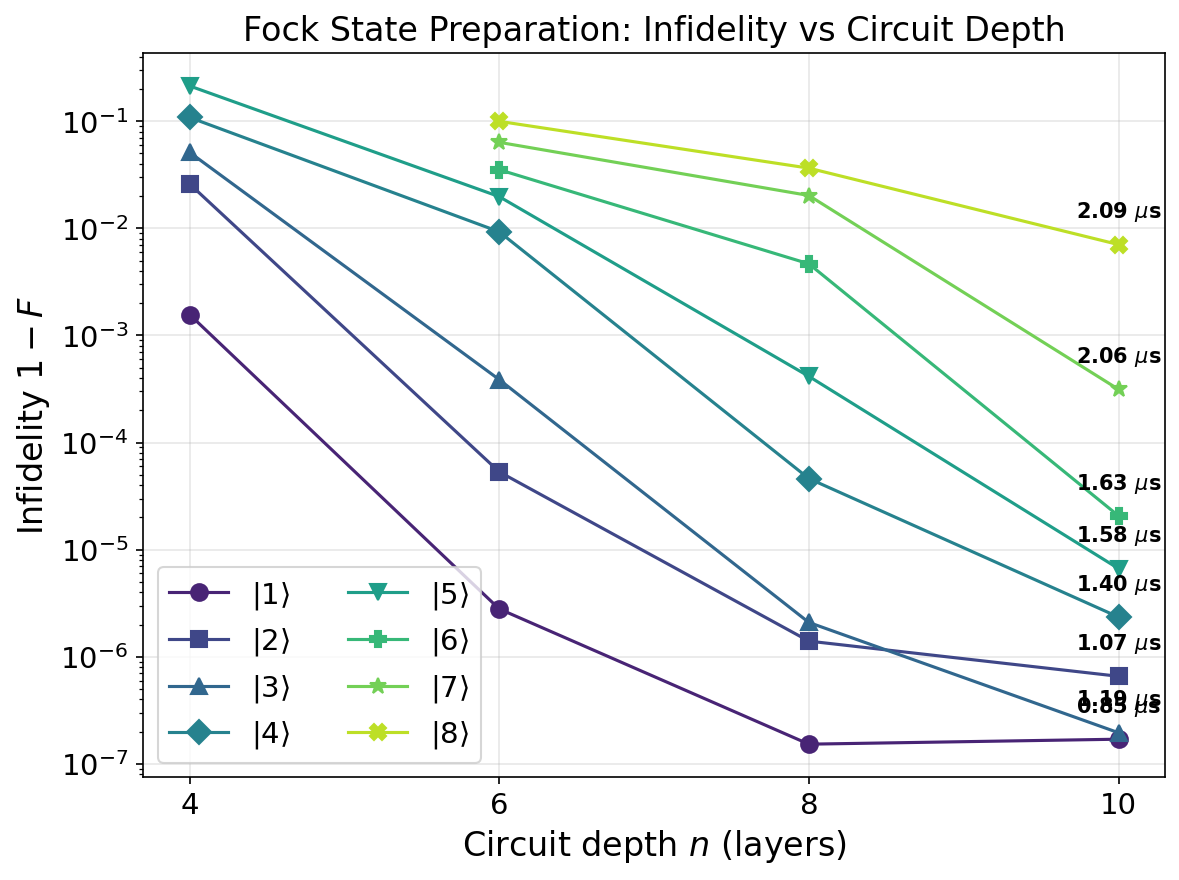

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']
colors = plt.cm.viridis(np.linspace(0.1, 0.9, 8))

for i, target_n in enumerate(fock_states):
    infids = []
    valid_depths = []
    for d in fock_depths:
        fid = results[target_n][d]['fidelity']
        if fid > 0.01:  # skip failed cases
            infids.append(1 - fid)
            valid_depths.append(d)
    if valid_depths:
        ax.semilogy(valid_depths, infids, f'{markers[i]}-', label=f'$|{target_n}\\rangle$',
                    markersize=8, color=colors[i])
        # Annotate depth-10 point with gate time
        if 10 in valid_depths:
            idx_10 = valid_depths.index(10)
            t_us = results[target_n][10]['time_us']
            ax.annotate(f'{t_us:.2f} $\\mu$s', xy=(10, infids[idx_10]),
                        xytext=(0, 10), textcoords='offset points',
                        ha='center', va='bottom', fontsize=10, color="black",
                        fontweight='bold')

ax.set_xlabel('Circuit depth $n$ (layers)', fontsize=16)
ax.set_ylabel('Infidelity $1 - F$', fontsize=16)
ax.set_title('Fock State Preparation: Infidelity vs Circuit Depth', fontsize=16)
ax.legend(fontsize=14, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xticks(fock_depths)
ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

---
## 4. Comprehensive I_c Comparison (5 Codes)

In [10]:
def gkp_square(Delta: float, N_trunc: int = 5) -> tuple[CoherentKet, CoherentKet]:
    """Finite-energy square GKP code."""
    log0 = gkp_coherent_dm(mu=0, N_trunc=N_trunc, Delta=Delta, lattice="square")
    log1 = gkp_coherent_dm(mu=1, N_trunc=N_trunc, Delta=Delta, lattice="square")
    return log0, log1

def gkp_hex(Delta: float, N_trunc: int = 5) -> tuple[CoherentKet, CoherentKet]:
    a_mag = jnp.sqrt(jnp.pi / jnp.sqrt(3.0))
    GKP_alpha = a_mag  # real
    GKP_beta = a_mag * jnp.exp(1.0j * jnp.pi / 3.0)  # 60° angle

    states = []
    for mu in range(2):
        cs = []
        ds = []
        for k in range(-N_trunc, N_trunc + 1):
            for l in range(-N_trunc, N_trunc + 1):
                disp = (2 * k + mu) * GKP_alpha + l * GKP_beta
                cs.append(
                    jnp.exp(
                        -1.0j * jnp.pi * (k * l + l * mu / 2.0)
                        - (Delta ** 2) * jnp.abs(disp) ** 2
                    )
                )
                ds.append(disp)
        states.append(CoherentKet(cs=jnp.array(cs), ds=jnp.array(ds)))
    return states[0], states[1]

In [11]:
def nbar_coherent_ket(state: CoherentKet) -> float:
    """Compute <n> for a CoherentKet.
    <n> = \sum_{ij} c_i * c_j <d_i| n|d_j> where <\alpha|n|\beta> = \bar{alpha}*\beta <\alpha|\beta>."""
    cs = state.cs
    ds = state.ds
    A = ds.shape[0]
    da = ds.reshape(A, 1)
    db = ds.reshape(1, A)
    ca = cs.reshape(A, 1)
    cb = cs.reshape(1, A)
    G = coherent_overlap(da, db)  # (A, A)
    # <alpha|n|beta> = conj(alpha)*beta * <alpha|beta>
    nhat_matrix = jnp.conj(da) * db * G
    return jnp.real(jnp.sum(jnp.conj(ca) * cb * nhat_matrix)) 

def nbar_code(log0: CoherentKet, log1: CoherentKet) -> float:
    """Mean photon number of the maximally mixed logical state (|0_L⟩⟨0_L| + |1_L⟩⟨1_L|)/2."""
    return 0.5 * (nbar_coherent_ket(log0) + nbar_coherent_ket(log1))

def find_gkp_delta_for_nbar(target_nbar: float, N_trunc: int = 5, lattice: str = "hex") -> float:
    """Find GKP Delta parameter that gives a target mean photon number."""
    gkp_fn = gkp_hex if lattice == "hex" else gkp_square
    lo, hi = 0.1, 1.0
    for _ in range(50):
        mid = (lo + hi) / 2.0
        l0, l1 = gkp_fn(mid, N_trunc)
        nb = float(nbar_code(l0, l1))
        if nb > target_nbar:  # larger Delta = more squeezing = lower nbar
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2.0

In [12]:
def singh_gkp_gaussian(
    mu: int,
    Delta: float,
    N_fock: int = GKP_N,
    n_terms: int = 15,
) -> jnp.ndarray:
    """Singh et al. Gaussian-envelope displaced-squeezed GKP (1D).

    Returns a Fock-basis ket vector.
    """
    r = -np.log(Delta)
    a = np.sqrt(np.pi / 2)
    S_r = dqsqueeze(N_fock, r)
    vac = jnp.zeros(N_fock, dtype=jnp.complex128).at[0].set(1.0)
    squeezed_vac = S_r @ vac
    psi = jnp.zeros(N_fock, dtype=jnp.complex128)
    for n in range(-n_terms, n_terms + 1):
        coeff = np.exp(-np.pi * Delta**2 * (2 * n + mu) ** 2 / 4.0)
        D_n = dqdisplace(N_fock, (2 * n + mu) * a)
        psi = psi + coeff * (D_n @ squeezed_vac)
    return psi / jnp.linalg.norm(psi)


def singh_gkp_binomial(
    mu: int,
    Delta: float,
    N_fock: int = GKP_N,
    N_binom: int | None = None,
) -> jnp.ndarray:
    """Singh et al. binomial-envelope displaced-squeezed GKP (1D).

    Returns a Fock-basis ket vector.
    """
    r = -np.log(Delta)
    a = np.sqrt(np.pi / 2)
    if N_binom is None:
        N_binom = int(0.32 / Delta**2)
    S_r = dqsqueeze(N_fock, r)
    vac = jnp.zeros(N_fock, dtype=jnp.complex128).at[0].set(1.0)
    squeezed_vac = S_r @ vac
    psi = jnp.zeros(N_fock, dtype=jnp.complex128)
    n_lo = -int((N_binom + mu) / 2)
    n_hi = int((N_binom + mu) / 2) - mu
    for n in range(n_lo, n_hi + 1):
        binom_coeff = np.sqrt(
            float(sp.comb(N_binom, n + mu + int(N_binom / 2), exact=True))
        )
        D_n = dqdisplace(N_fock, (2 * n + mu) * a)
        psi = psi + binom_coeff * (D_n @ squeezed_vac)
    return psi / jnp.linalg.norm(psi)


Computing I_c for 5 codes x 6 gammas (this takes a few minutes)...
  gamma=0.01, target nbar=3.20


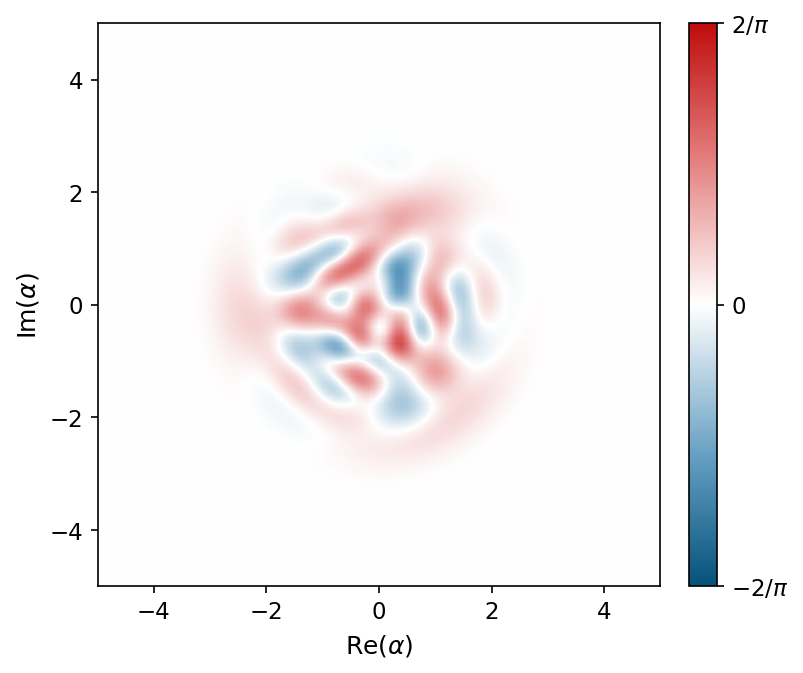

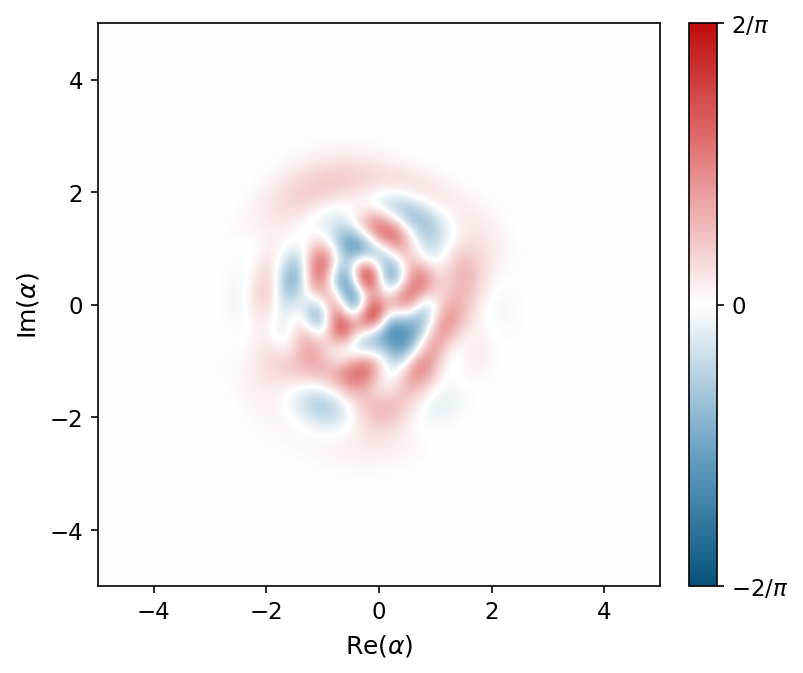

  gamma=0.05, target nbar=3.34


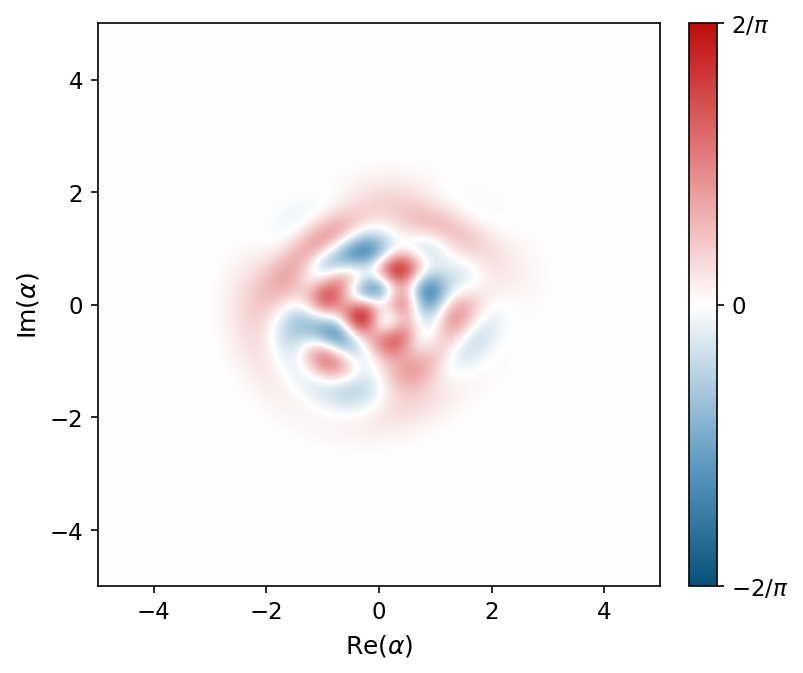

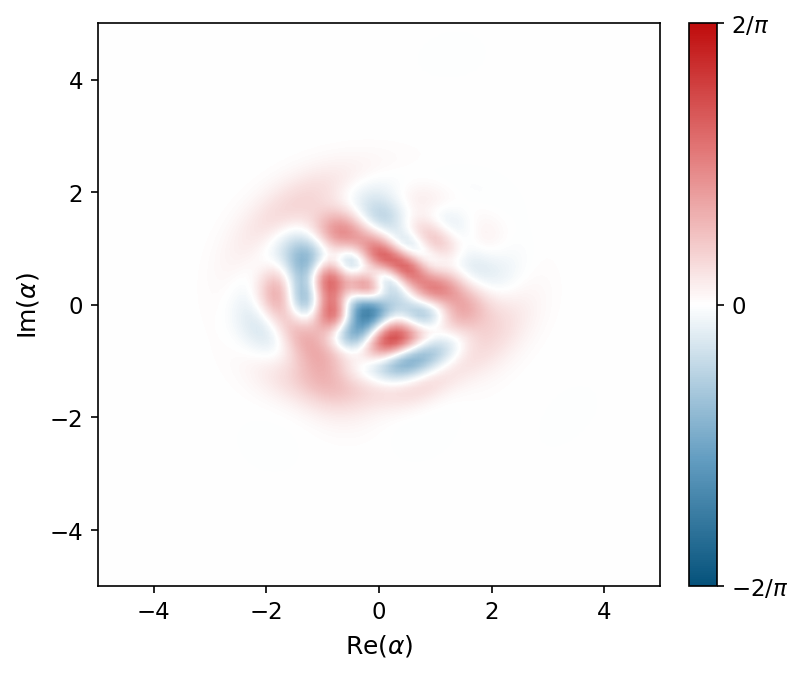

  gamma=0.10, target nbar=3.37


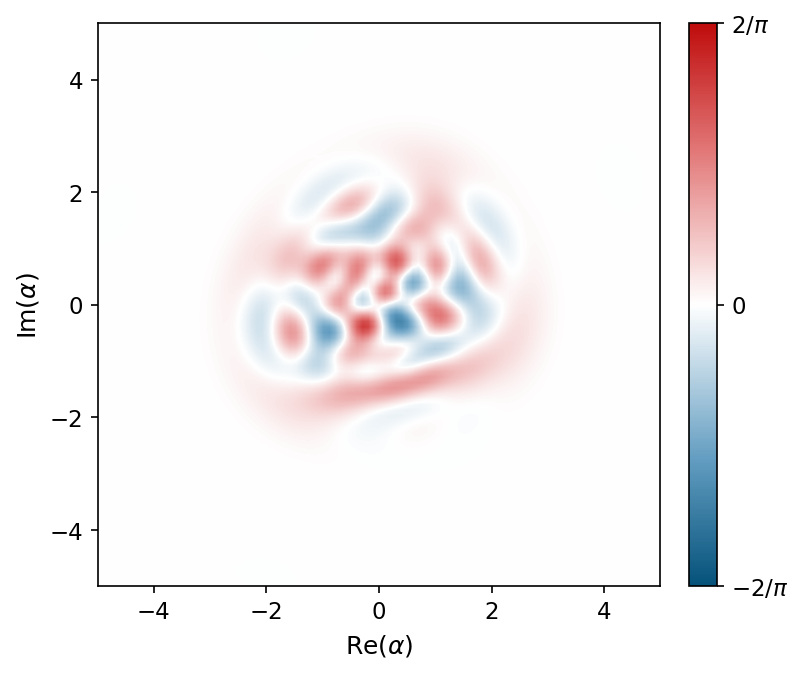

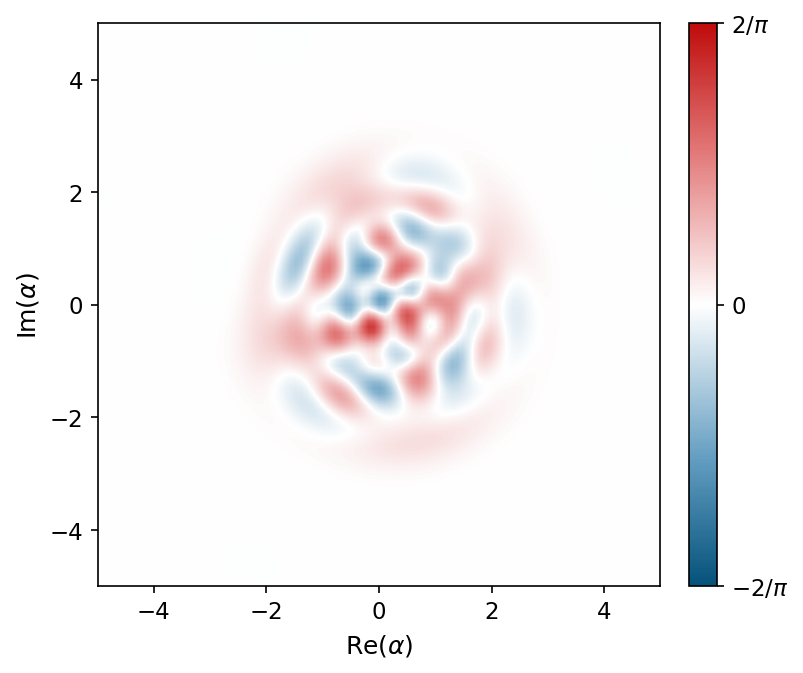

  gamma=0.15, target nbar=3.67


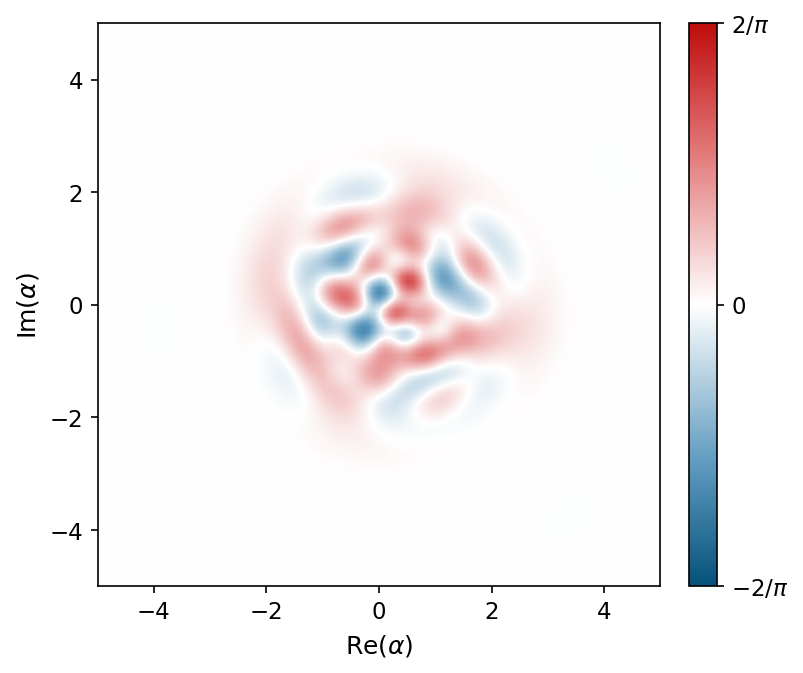

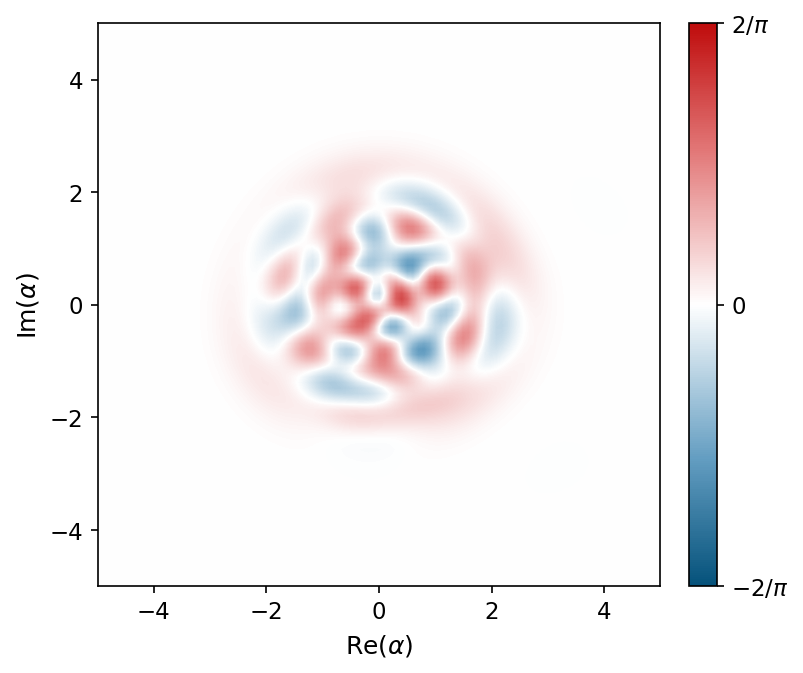

  gamma=0.20, target nbar=3.77


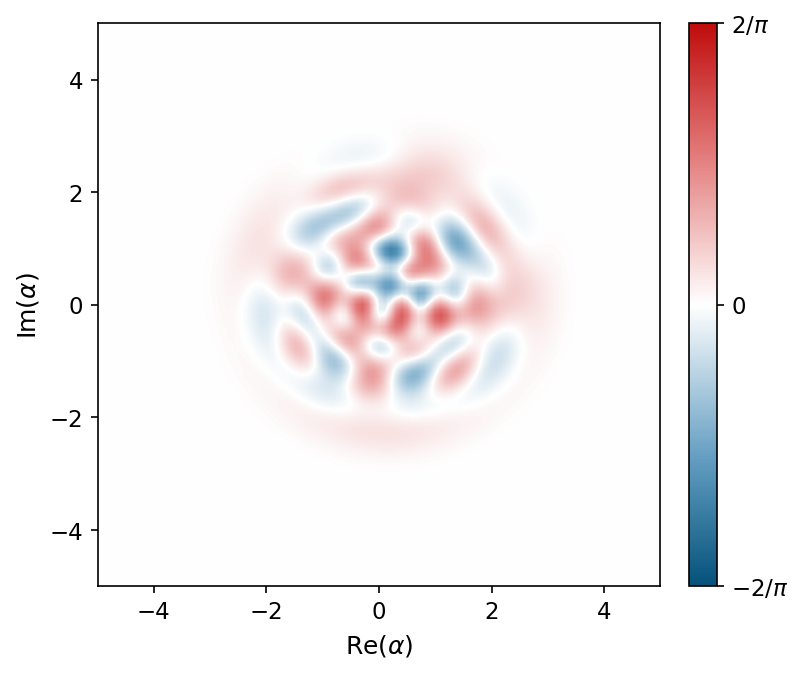

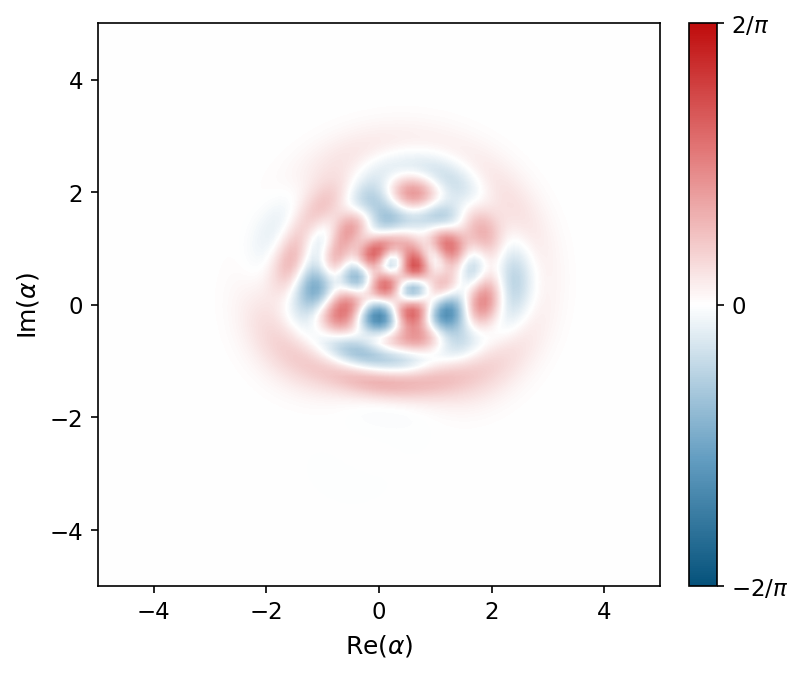

  gamma=0.30, target nbar=3.59


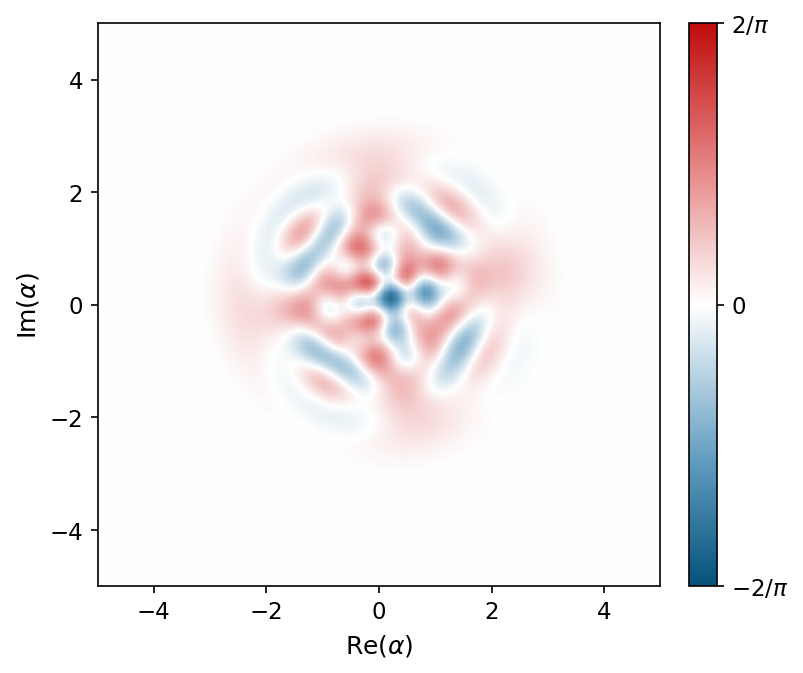

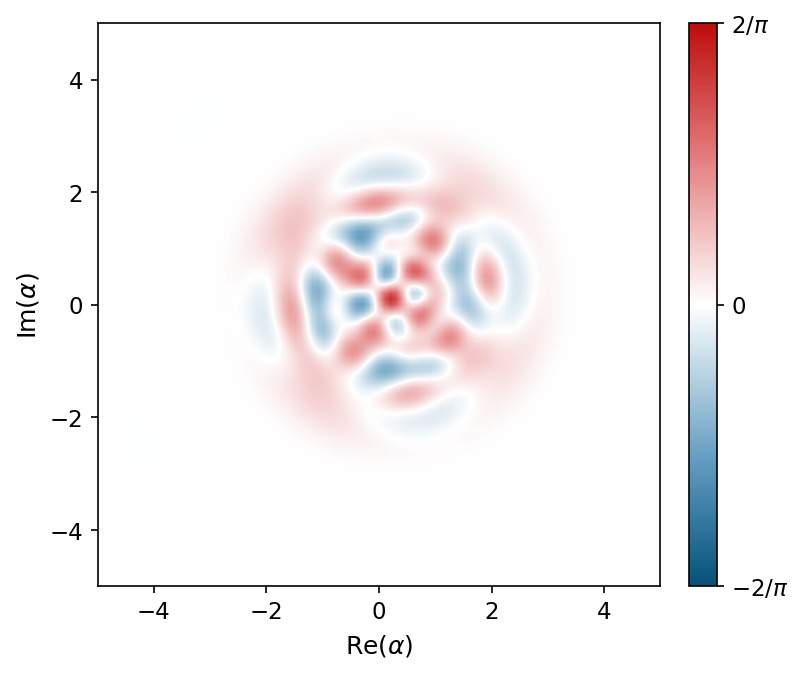


Coherent Information Under Pure Loss (8 Codes) — RECOMPUTED
Code                    0.01      0.05      0.10      0.15      0.20      0.30
----------------------------------------------------------------------------------------------------
Hex GKP (coherent superposition)    0.9999    0.9990    0.9927    0.9771    0.9391    0.7464
Square GKP (coherent superposition)    0.9999    0.9980    0.9888    0.9698    0.9278    0.7319
Floating (optimized)    0.9991    0.9947    0.9856    0.9463    0.8900    0.6710
Displaced-Squeezed Gaussian Envelope    0.9999    0.9991    0.9941    0.9811    0.9481    0.7676
Displaced Squeezed Binomial Envelope    0.9959    0.9826    0.9632    0.9348    0.8849    0.6873


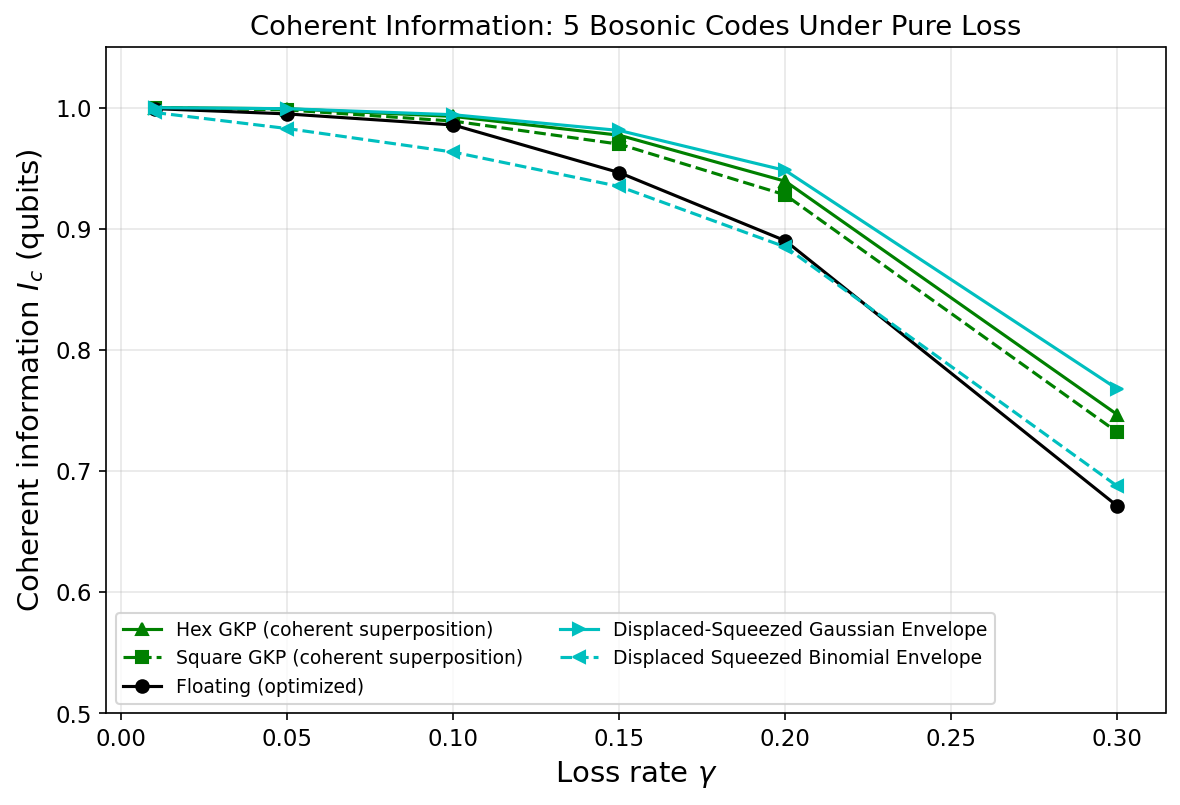

In [13]:
# 5-code I_c under pure loss — RECOMPUTED from code definitions
# Load stored results for cross-check
ic_stored = np.load(f'{DATA}/Ic_comparison_results.npz', allow_pickle=True)
fb_vac = np.load(f'{DATA}/results_vacuum.npz', allow_pickle=True)
gammas_ic = np.array([0.01, 0.05, 0.10, 0.15, 0.20, 0.30])
gamma_strs = ['0.01', '0.05', '0.10', '0.15', '0.20', '0.30']
nbar_targets = ic_stored['nbar_targets']

# Construct all 8 codes and compute I_c at each gamma
code_names = ['Hex GKP (coherent superposition)', 'Square GKP (coherent superposition)', 'Floating (optimized)', 'Displaced-Squeezed Gaussian Envelope', 'Displaced Squeezed Binomial Envelope']
Ic_all = np.zeros((8, len(gammas_ic)))

print('Computing I_c for 5 codes x 6 gammas (this takes a few minutes)...')
for j, gam in enumerate(gammas_ic):
    gam = float(gam)
    nbar = float(nbar_targets[j])
    print(f'  gamma={gam:.2f}, target nbar={nbar:.2f}')

    # 0: Hex GKP
    delta_hex = find_gkp_delta_for_nbar(nbar, lattice="hex")
    l0, l1 = gkp_hex(delta_hex)
    Ic_all[0, j] = pureloss_coherent_info_from_coherent_kets(l0, l1, gam, loss_rank=15)

    # 1: Square GKP (coherent-basis)
    delta_sq = find_gkp_delta_for_nbar(nbar, lattice="square")
    l0, l1 = gkp_square(delta_sq)
    Ic_all[1, j] = pureloss_coherent_info_from_coherent_kets(l0, l1, gam, loss_rank=15)

    # 2: Floating-basis (NC=10, F_e-optimized)
    gs = gamma_strs[j]
    cs0 = jnp.array(fb_vac[f'nc10_g{gs}_cs0'])
    ds0 = jnp.array(fb_vac[f'nc10_g{gs}_ds0'])
    cs1 = jnp.array(fb_vac[f'nc10_g{gs}_cs1'])
    ds1 = jnp.array(fb_vac[f'nc10_g{gs}_ds1'])
    Ic_all[2, j] = pureloss_coherent_info_from_coherent_kets(
        CoherentKet(cs0, ds0), CoherentKet(cs1, ds1), gam, loss_rank=15)
    
    dq.plot.wigner(CoherentKet(cs0, ds0).to_fock_basis())
    plt.show()
    dq.plot.wigner(CoherentKet(cs1, ds1).to_fock_basis())
    plt.show()

    # 3: Singh Gaussian GKP — Fock-basis construction
    delta_singh = find_gkp_delta_for_nbar(nbar, lattice="hex")  # match nbar via hex delta
    psi0_sg = singh_gkp_gaussian(0, delta_singh)
    psi1_sg = singh_gkp_gaussian(1, delta_singh)
    Ic_all[3, j] = pureloss_coherent_info_from_kets(psi0_sg, psi1_sg, gam, loss_rank=15)

    # 4: Singh Binomial GKP
    psi0_sb = singh_gkp_binomial(0, delta_singh)
    psi1_sb = singh_gkp_binomial(1, delta_singh)
    Ic_all[4, j] = pureloss_coherent_info_from_kets(psi0_sb, psi1_sb, gam, loss_rank=15)

# Table
print('\nCoherent Information Under Pure Loss (8 Codes) — RECOMPUTED')
print('=' * 100)
header = f'{"Code":<18s}'
for g_val in gammas_ic:
    header += f'{g_val:>10.2f}'
print(header)
print('-' * 100)
styles = ['g^-', 'gs--', 'ko-', 'c>-', 'c<--']# 'bs-', 'rD-', 'mv-']
for i, name in enumerate(code_names):
    row = f'{name:<18s}'
    for v in Ic_all[i]:
        row += f'{v:>10.4f}'
    print(row)

# Plot
fig, ax = plt.subplots(figsize=(8, 5.5))
for i, (name, style) in enumerate(zip(code_names, styles)):
    ax.plot(gammas_ic, Ic_all[i], style, label=name, markersize=6)
ax.set_xlabel('Loss rate $\\gamma$',fontsize=14)
ax.set_ylabel('Coherent information $I_c$ (qubits)',fontsize=14)
ax.set_title('Coherent Information: 5 Bosonic Codes Under Pure Loss')
ax.legend(loc='lower left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.5, 1.05])
plt.tight_layout()
plt.savefig(f'{FIGS}/fig_aggregated_Ic.pdf',
            bbox_inches='tight', dpi=150)
plt.show()

---
## 5. ECD Optimization Tool Examples

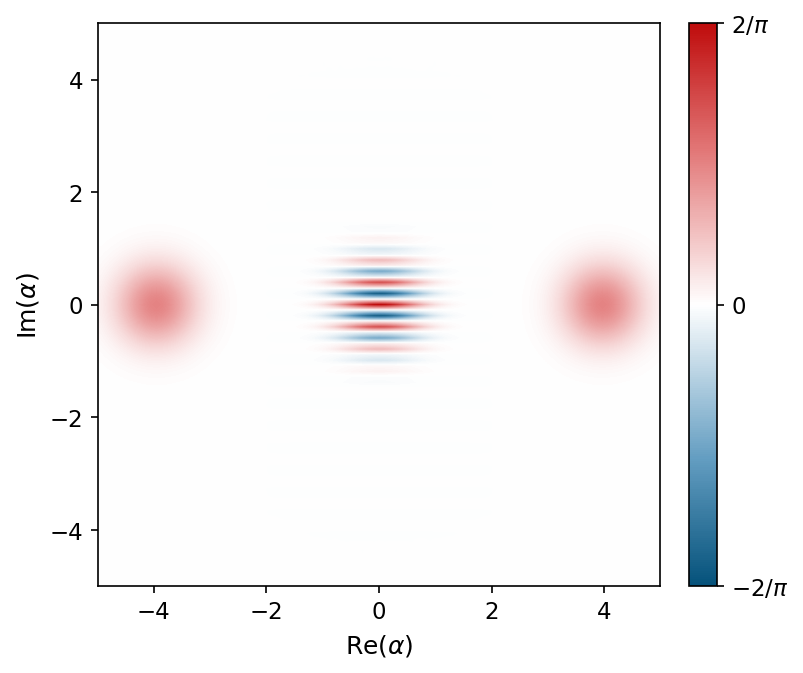

In [14]:
c_rho_cat_2 = CoherentKet(
    cs=jnp.array([1,1]),
    ds=jnp.array([4, -4]),
)
fock_rho_cat_native = c_rho_cat_2.to_fock_basis()
dq.plot.wigner(fock_rho_cat_native)

This optimization utility takes in the target CoherentKet and optimizes the ECD sequences with length N_depth. The CDs are initialized with iid complex normal values scaled by random_dist, and the angles are iid uniform in [0,2*random_angle] . It is *strongly* suggested that random_dist is quite small, though for states with larger separation, this value might be larger.

In [15]:
N_depth = 6
inits = jnp.zeros((6,4),dtype=jnp.complex64)
best_cat_2_params, best_cat_2_loss = optimize_ECD_state_prep(
    target_state=c_rho_cat_2,
    restarts=2,
    steps=15000,
    lr=.001,
    N_depth=N_depth,
    random_dist=.1,
    random_angle=1,
    initial=inits,
)

/opt/miniconda3/envs/jiang/lib/python3.11/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=complex64 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/opt/miniconda3/envs/jiang/lib/python3.11/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=complex64 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


Restart 0, Step 0, 1 - F = 0.999960
Restart 0, Step 100, 1 - F = 0.999446
Restart 0, Step 200, 1 - F = 0.991131
Restart 0, Step 300, 1 - F = 0.923865
Restart 0, Step 400, 1 - F = 0.767389
Restart 0, Step 500, 1 - F = 0.624176
Restart 0, Step 600, 1 - F = 0.551697
Restart 0, Step 700, 1 - F = 0.497589
Restart 0, Step 800, 1 - F = 0.444817
Restart 0, Step 900, 1 - F = 0.386342
Restart 0, Step 1000, 1 - F = 0.314394
Restart 0, Step 1100, 1 - F = 0.231388
Restart 0, Step 1200, 1 - F = 0.154757
Restart 0, Step 1300, 1 - F = 0.098800
Restart 0, Step 1400, 1 - F = 0.063354
Restart 0, Step 1500, 1 - F = 0.041903
Restart 0, Step 1600, 1 - F = 0.028888
Restart 0, Step 1700, 1 - F = 0.020910
Restart 0, Step 1800, 1 - F = 0.016023
Restart 0, Step 1900, 1 - F = 0.013071
Restart 0, Step 2000, 1 - F = 0.011331
Restart 0, Step 2100, 1 - F = 0.010334
Restart 0, Step 2200, 1 - F = 0.009783
Restart 0, Step 2300, 1 - F = 0.009487
Restart 0, Step 2400, 1 - F = 0.009332
Restart 0, Step 2500, 1 - F = 0.00925

In [16]:
print(best_cat_2_params) # optimized circuit parameters
print(best_cat_2_loss) # infidelity

[[-3.8820736e+00+6.5045834e-02j  1.4782501e+00+0.0000000e+00j
   1.5707426e+00+0.0000000e+00j  0.0000000e+00+0.0000000e+00j]
 [ 4.1272153e-05-9.3759618e-06j  3.7607037e-06+0.0000000e+00j
  -1.9882201e+00+0.0000000e+00j  0.0000000e+00+0.0000000e+00j]
 [-3.9217365e+00-5.1998768e-02j  9.2551455e-02+0.0000000e+00j
  -1.9882284e+00+0.0000000e+00j  0.0000000e+00+0.0000000e+00j]
 [ 1.6085473e-03+1.0193627e-01j -3.1157565e-06+0.0000000e+00j
   1.3813082e+00+0.0000000e+00j  0.0000000e+00+0.0000000e+00j]
 [-2.7755842e-01+8.7244483e-03j  9.1681095e-06+0.0000000e+00j
   1.4011477e+00+0.0000000e+00j  0.0000000e+00+0.0000000e+00j]
 [ 3.8455054e-03+9.8617032e-02j -8.4202552e-01+0.0000000e+00j
   1.6020298e+00+0.0000000e+00j  0.0000000e+00+0.0000000e+00j]]
1.5528796108998932e-06


Verifying that it works (in the Fock basis)

Fidelity: 0.999998404271382


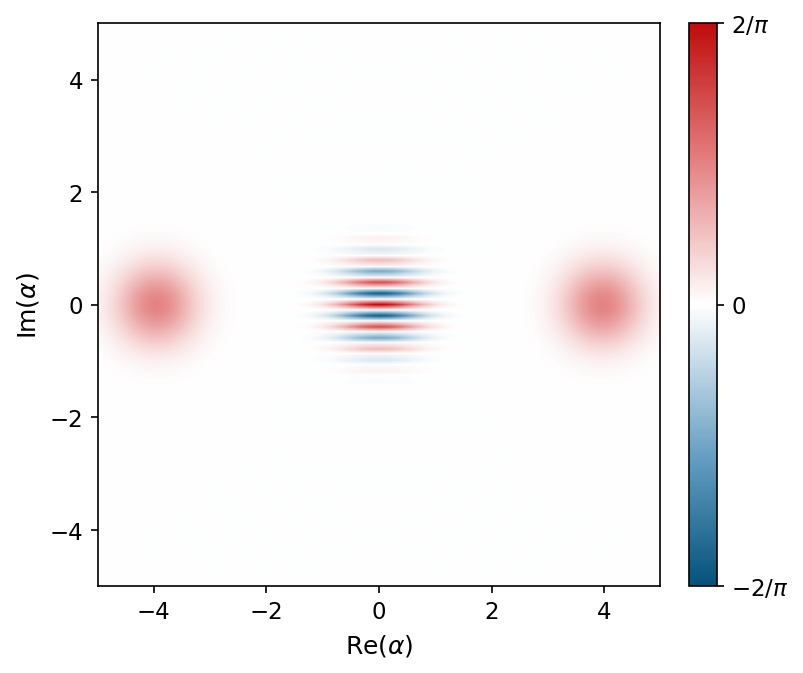

In [17]:
prepped_state = apply_kraus_map( # applies any Kraus map operators in Fock basis
    traceout_unitary( # traces out ancilla
        compose_ECD_layers(best_cat_2_params) # generates joint unitary in (GKP_N,2) format (ie 200x200 in this case)
    ),
    dqfock_dm(GKP_N,0) # vacuum initialization
)
dq.plot.wigner(prepped_state)
print("Fidelity:", jnp.real(jnp.trace(prepped_state@c_rho_cat_2.to_fock_basis())))

### Recommendations for Long Optimizations
 - 30k steps with lr=.001 works well
 - Higher N_depth is more expressive, but it will take longer to find a good preset. It is recommended to start off with something like N_depth = 8 and find a decent set of parameters then pad the end with zeros and use it as a initialization for N_depth = 9. Repeat this process up to ~N_depth=14 (when it gets very slow) or until the desired fidelity
 - For states with many coherent states like GKP, use a "checkpointed" method like prepping the x-quadrature coherent states and then optimizing the transfer (see below) to eg the full GKP lattice.

In [18]:
start_state = CoherentKet(
    cs=jnp.array([1,1]),
    ds=jnp.array([2, -2]),
) # 2-legged cat
final_state = CoherentKet(
    cs=jnp.array([1,1,1,1]),
    ds=jnp.array([2+2j, -2+2j,2-2j,-2-2j]),
) # 4-legged cat

In [19]:
transfer_parameters, transfer_infidelity = optimize_ECD_state_transfer(
    start_state=start_state,
    final_state=final_state,
    T_depth=1, # this is how many ancilla traceouts to use, 1 is recommended for most
    N_depth=7,
    lr=.01, # you may need to fiddle with this
    steps=20000,
    restarts=20,
    random_dist=1., # larger than just the cat prep
    random_angle=jnp.pi
)

/opt/miniconda3/envs/jiang/lib/python3.11/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=complex64 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/opt/miniconda3/envs/jiang/lib/python3.11/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=complex64 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


[[[ 0.19303176-0.71746963j  3.068907  +0.j
    4.9466505 +0.j          3.3472817 +0.j        ]
  [-1.201344  +0.69866586j  5.279704  +0.j
    4.731116  +0.j          2.4353688 +0.j        ]
  [-0.43424255+0.09547067j  2.4109752 +0.j
    4.1373935 +0.j          2.6578789 +0.j        ]
  [-1.2761    -0.13352372j  4.351012  +0.j
    3.9585328 +0.j          0.4778942 +0.j        ]
  [-0.05790696-1.8692693j   2.8127956 +0.j
    5.9612913 +0.j          5.931212  +0.j        ]
  [-0.38786745+0.33576593j  3.3394318 +0.j
    1.9696047 +0.j          0.41967693+0.j        ]
  [-0.8731323 +0.721873j    5.3870034 +0.j
    3.9385257 +0.j          2.5695803 +0.j        ]]]
Restart 0, Step 0, 1 - F = 0.969683
Restart 0, Step 100, 1 - F = 0.369197
Restart 0, Step 200, 1 - F = 0.058109
Restart 0, Step 300, 1 - F = 0.045449
Restart 0, Step 400, 1 - F = 0.015776
Restart 0, Step 500, 1 - F = 0.015012
Restart 0, Step 600, 1 - F = 0.014800
Restart 0, Step 700, 1 - F = 0.014705
Restart 0, Step 800, 1 - F = 0.

In [ ]:
transfer_parameters # note the shape here is (1,N_depth,4) because you can do multiple layers

Array([[[-6.8878257e-01+1.6076637e-03j,  1.5707960e+00+0.0000000e+00j,
          4.7123899e+00+0.0000000e+00j,  0.0000000e+00+0.0000000e+00j],
        [-2.2172287e-01+2.7975757e+00j,  5.2348923e-08+0.0000000e+00j,
          6.1576122e-01+0.0000000e+00j,  0.0000000e+00+0.0000000e+00j],
        [-8.5800284e-01+7.7373040e-01j,  6.2831883e+00+0.0000000e+00j,
          2.9581320e+00+0.0000000e+00j,  0.0000000e+00+0.0000000e+00j],
        [-1.2439246e+00-1.2776485e-03j,  3.1415918e+00+0.0000000e+00j,
          7.7235383e-01+0.0000000e+00j,  0.0000000e+00+0.0000000e+00j],
        [-1.0471054e+00+7.8727275e-01j,  3.1415937e+00+0.0000000e+00j,
          2.9605702e-01+0.0000000e+00j,  0.0000000e+00+0.0000000e+00j],
        [-7.7100027e-01+7.8798491e-01j,  3.1415894e+00+0.0000000e+00j,
          5.8172779e+00+0.0000000e+00j,  0.0000000e+00+0.0000000e+00j],
        [ 5.4642320e-01-1.9753475e-03j,  6.1957383e+00+0.0000000e+00j,
          2.4499464e+00+0.0000000e+00j,  0.0000000e+00+0.0000000e+00j]]

Fidelity: 0.9988420066839783


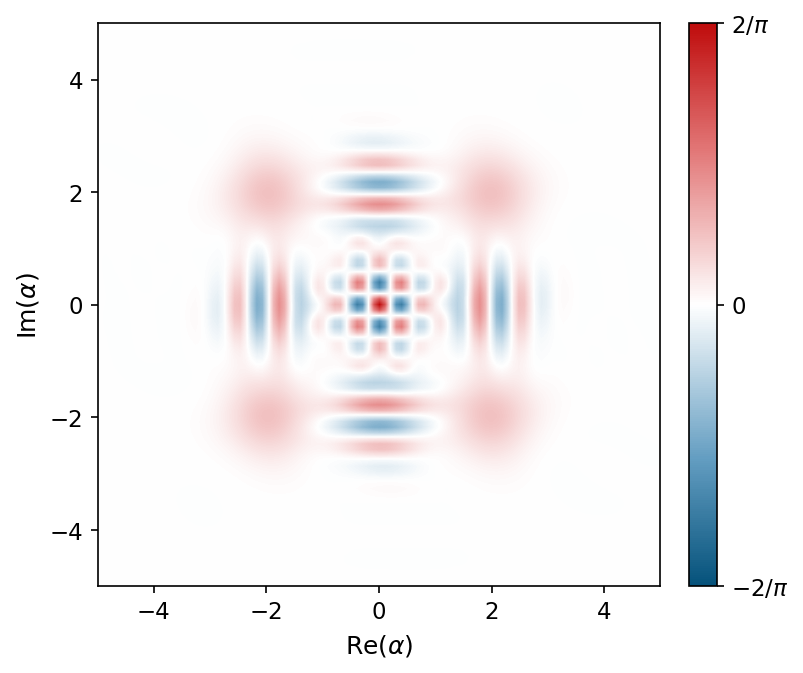

In [23]:
transferred_state = apply_kraus_map( # run map
    traceout_unitary( # traceout ancilla
        compose_ECD_layers(transfer_parameters[0]) # compile to unitary
    ),
    start_state.to_fock_basis() # starting point
)
dq.plot.wigner(transferred_state)
print("Fidelity:",jnp.real(jnp.trace(transferred_state@final_state.to_fock_basis())))